In [12]:
import numpy as np
import matplotlib.pyplot as plt


Definir los valores de los parámetros

In [13]:
# Valores de las variables
Nind = 5
Lind = 20
Pc = 0.7
Pm = 1/15
Maxgen = 100
Nvar = 1
rango  = np.array([[0, 0.875]])

Definicion de funciones

In [14]:
def creapob(Nind, Lind):
    return np.random.randint(0, 2, size=(Nind, Lind))

def decodifica(genotipo, rango):
    Nvar = rango.shape[0]          # ← fix: shape[0] = nº de variables (1)
    Nind, Lind = genotipo.shape
    Lvar = Lind // Nvar
    potencias = 2 ** np.arange(Lvar)
    fenotipo = np.zeros((Nind, Nvar))
    for i in range(Nind):
        for j in range(Nvar):
            fenotipo[i, j] = np.sum(potencias * genotipo[i, j*Lvar : j*Lvar + Lvar])
    for i in range(Nvar):
        fenotipo[:, i] = rango[i, 0] + ((rango[i, 1] - rango[i, 0]) / (2**Lvar - 1)) * fenotipo[:, i]
    return fenotipo

def objfun(fenotipo):
    Nind, _ = fenotipo.shape
    objv = np.zeros((Nind, 1))
    for i in range(Nind):
        x = fenotipo[i, 0]
        t = (11/2)*x - (7/2)          # Transformación del dominio
        objv[i, 0] = 1 - t**2 * np.cos(t) + 1 + 2
    return objv

def rankeo(objv, direccion):
    SP = 2
    Nind, _ = objv.shape
    aptitud = np.zeros((Nind, 1))
    nuevo_objv = np.sort(objv, axis=0) if direccion == 1 else np.sort(-objv, axis=0)
    apt = 2 - SP + 2*(SP-1)*(np.arange(Nind)/(Nind-1))
    posori = np.argsort(nuevo_objv, axis=0).flatten()
    aptitud[posori, 0] = apt
    return aptitud

def ruleta(genotipo, aptitud):
    Nind = aptitud.shape[0]
    total = np.sum(aptitud)
    acumulada = np.cumsum(aptitud / total)
    idx = np.zeros(Nind, dtype=int)
    for i in range(Nind):
        aux = np.where(acumulada >= np.random.rand())[0]
        idx[i] = aux[0]
    return genotipo[idx, :]

def xunpunto(nuevo_gen, Pc):
    Nind, Lind = nuevo_gen.shape
    aux_gen = nuevo_gen.copy()
    for i in range(0, Nind - 1, 2):
        if np.random.rand() <= Pc:
            corte = np.random.randint(1, Lind)
            aux_gen[i,   :] = np.concatenate((nuevo_gen[i,   :corte], nuevo_gen[i+1, corte:]))
            aux_gen[i+1, :] = np.concatenate((nuevo_gen[i+1, :corte], nuevo_gen[i,   corte:]))
    return aux_gen

def muta(nuevo_gen, Pm):
    mask = np.random.rand(*nuevo_gen.shape) <= Pm
    return np.logical_xor(nuevo_gen, mask).astype(int)

Crear la población inicial

In [15]:
genotipo = creapob(Nind, Lind)
fenotipo = decodifica(genotipo, rango)
objv = objfun(fenotipo)
Mejor = np.full((Maxgen, 1), np.nan)
Mejor_cromosoma = np.zeros((Maxgen, Lind))

Ciclo Evolutivo

In [16]:
generaciones = 1
while generaciones < Maxgen:
    aptitud  = rankeo(objv, 1)
    nuevo_gen  = ruleta(genotipo, aptitud)
    nuevo_gen  = xunpunto(nuevo_gen, Pc)
    nuevo_gen  = muta(nuevo_gen, Pm)
    nuevo_feno = decodifica(nuevo_gen, rango)
    nuevo_objv = objfun(nuevo_feno)

    genotipo = nuevo_gen
    objv     = nuevo_objv

    idx = np.argmax(objv)
    Mejor[generaciones]              = objv[idx]
    Mejor_cromosoma[generaciones, :] = genotipo[idx, :]
    generaciones += 1

Grafica

In [17]:
idx_best = np.nanargmax(Mejor)
mejor_x  = decodifica(Mejor_cromosoma[idx_best:idx_best+1, :], rango)[0, 0]
print(f"Mejor f(x)  = {Mejor[idx_best][0]:.4f}")
print(f"x           = {mejor_x:.4f}")

Mejor f(x)  = 15.4639
x           = 0.0006


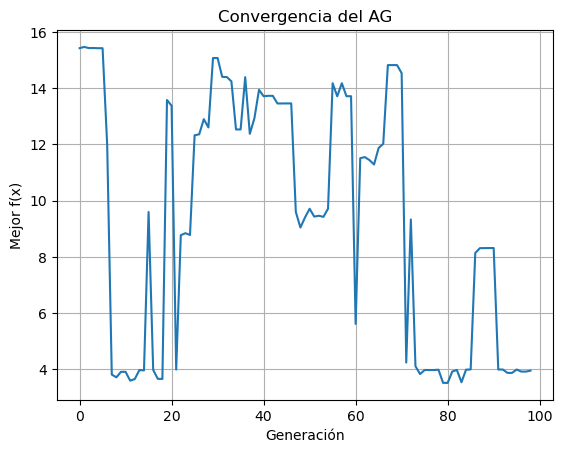

In [18]:
plt.figure()
plt.plot(Mejor[1:])
plt.xlabel('Generación')
plt.ylabel('Mejor f(x)')
plt.title('Convergencia del AG')
plt.grid(True)
plt.show()

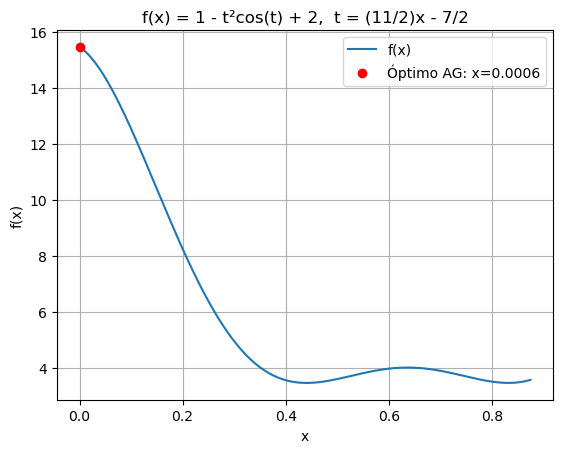

In [19]:
x_vals = np.linspace(0, 0.875, 500)
t_vals = (11/2)*x_vals - (7/2)
f_vals = 1 - t_vals**2 * np.cos(t_vals) + 1 + 2

plt.figure()
plt.plot(x_vals, f_vals, label='f(x)')
plt.scatter([mejor_x], [Mejor[idx_best]], color='red', zorder=5, label=f'Óptimo AG: x={mejor_x:.4f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('f(x) = 1 - t²cos(t) + 2,  t = (11/2)x - 7/2')
plt.legend()
plt.grid(True)
plt.show()